# 3주차 · 센서 시계열 탐색
데이터: 식각 장비 FDC 트레이스 (수업용 생성 데이터)

---

## 오늘의 상황

식각 장비는 웨이퍼 한 장을 처리하는 60초 동안 센서 값을 1초에 한 번씩 기록합니다.
이걸 FDC(Fault Detection and Classification) 트레이스라고 부릅니다.

장비 엔지니어가 이렇게 말합니다.

> 불량 난 웨이퍼들이 있는데, 트레이스를 보면 뭔가 이상한 게 보일 겁니다. 찾아주세요.

오늘은 트레이스를 그려보고, 60줄짜리 시계열을 모델이 먹을 수 있는 한 줄로 줄이는 것까지 합니다.
모델은 다음 주에 만듭니다.

## 오늘 할 것

1. 트레이스 열어보기
2. 웨이퍼 한 장을 눈으로 보기
3. 스텝 구조 파악하기
4. 정상과 이상을 겹쳐 그리기
5. 웨이퍼 한 장을 한 줄로 줄이기
6. 기울기라는 특징 만들기
7. 어떤 특징이 어떤 이상을 잡는가

## 규칙

`# TODO` 가 붙은 셀만 작성하면 됩니다. 각 미션 뒤에 자가진단 셀이 있으니
`[통과]` 가 뜰 때까지 스스로 고쳐보세요. 막히면 물어보되 먼저 15분은 혼자 붙들어 보세요.
정답을 베끼는 것보다 틀리고 고치는 과정이 점수에 반영됩니다.

---

## 준비

In [8]:
# 이 셀은 그대로 실행하세요.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

from numpy.ma.core import ravel
from pandas import merge
from sklearn.externals.array_api_compat.dask.array import asarray

_have = {f.name for f in fm.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    if _f in _have:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

DATA = Path('D:/박재민/bigdata_use/etch_fdc')   # 폴더를 옮겼다면 이 줄만 고치세요

def check(name, cond, hint=''):
    if cond:
        print('[통과] ' + name)
    else:
        print('[실패] ' + name + (('  ->  ' + str(hint)) if hint else ''))

print('폰트:', plt.rcParams['font.family'][0], '| 데이터 폴더:', DATA.exists())

폰트: Malgun Gothic | 데이터 폴더: True


---

## 미션 1 · 트레이스 열어보기

지난 두 주와 데이터가 다릅니다. 지금까지는 웨이퍼 한 장에 값이 한 줄이었는데,
이번에는 웨이퍼 한 장이 **60줄**입니다. 1초에 한 번씩 60초를 기록했기 때문입니다.
이런 걸 시계열이라고 합니다.

`traces.csv` 와 `wafer_info.csv` 를 불러오고 구조를 확인하세요.

센서는 여덟 개입니다.

| 컬럼 | 뜻 | 단위 |
|---|---|---|
| `rf_forward_W` | RF 순방향 전력 | W |
| `rf_reflected_W` | RF 반사 전력. 정합이 나쁘면 올라간다 | W |
| `chamber_pressure_mTorr` | 챔버 압력 | mTorr |
| `ar_flow_sccm` | 아르곤 유량 | sccm |
| `cf4_flow_sccm` | CF4 유량 | sccm |
| `esc_temp_C` | 정전척 온도 | degC |
| `he_backside_Torr` | 웨이퍼 뒷면 헬륨 압력 | Torr |
| `endpoint_intensity` | 종점 검출 발광 세기 | a.u. |

In [13]:
# TODO 1-1: 두 파일 불러오기
#   traces.csv 는 tr 로, wafer_info.csv 는 wi 로
#   wafer_info 의 timestamp 는 parse_dates 로 읽으세요
tr = pd.read_csv(Path.joinpath(DATA,'traces.csv'), encoding='utf-8')
wi = pd.read_csv(Path.joinpath(DATA,'wafer_info.csv'), encoding='utf-8', parse_dates=['timestamp'])

# TODO 1-2: 각각의 크기, 웨이퍼 수, 웨이퍼 한 장당 행 수를 출력
#   힌트: tr.wafer_id.nunique() 로 웨이퍼 수를 세고, 전체 행 수를 그것으로 나누세요
print(len(tr))
print(tr.wafer_id.nunique())
print(len(tr)/tr.wafer_id.nunique())


# TODO 1-3: 이상 유형(fault_type)별 웨이퍼 수
#   힌트: value_counts(). 자가진단이 fault_counts.get('NORMAL') 을 봅니다
fault_counts = wi['fault_type'].value_counts()
print(fault_counts)

24000
400
60.0
fault_type
NORMAL            316
RF_UNSTABLE        30
PRESSURE_DRIFT     30
GAS_LEAK           24
Name: count, dtype: int64


자가진단 1 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [14]:
check('traces 24000행 11열', tr is not None and tr.shape == (24000, 11), None if tr is None else tr.shape)
check('웨이퍼 400장', wi is not None and len(wi) == 400)
check('장당 60행', tr is not None and len(tr) // tr.wafer_id.nunique() == 60)
check('정상 316장', fault_counts is not None and fault_counts.get('NORMAL') == 316, None if fault_counts is None else dict(fault_counts))

[통과] traces 24000행 11열
[통과] 웨이퍼 400장
[통과] 장당 60행
[통과] 정상 316장


---

## 미션 2 · 웨이퍼 한 장을 눈으로 보기

정상 웨이퍼 `WF0001` 을 골라 여덟 개 센서를 각각 그려보세요.
`plt.subplots(4, 2)` 로 여덟 칸을 만들고 한 칸에 센서 하나씩 넣습니다.

그리고 나서 그래프를 보며 답해 보세요. 60초 동안 무슨 일이 일어났습니까.
값이 계단처럼 바뀌는 지점이 보입니까.

숫자 표만 보고 시계열을 이해하려 들면 안 됩니다. 일단 그려야 합니다.

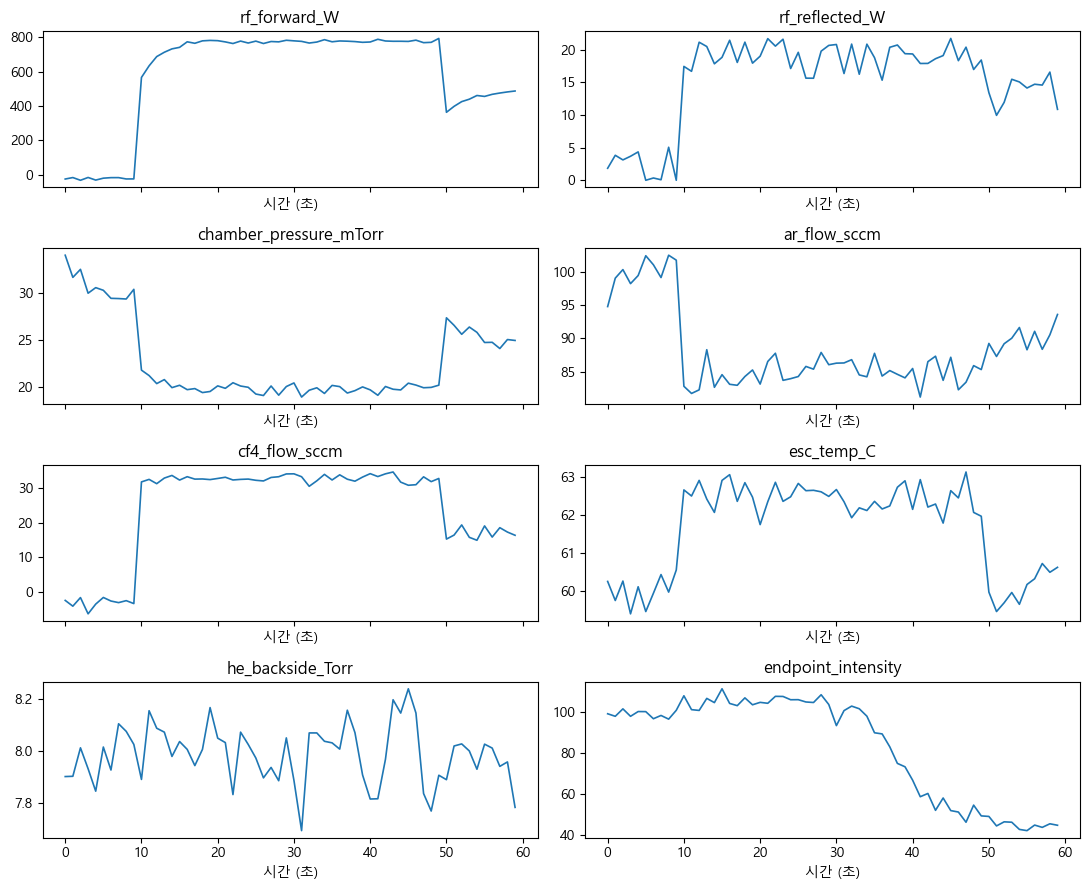

In [54]:
# TODO 2-1: WF0001 의 데이터만 뽑기 (60행이어야 합니다)
one = tr[tr['wafer_id'] == 'WF0001']

# TODO 2-2: 4행 2열 subplot 에 센서 8개를 각각 그리기
#   x축은 t_sec, 각 칸에 센서 이름을 제목으로
#   힌트: plt.subplots(4, 2, sharex=True) 가 돌려주는 axes 는 4x2 배열입니다.
#         axes.ravel() 로 8칸짜리 한 줄로 편 다음 SENSORS 와 zip 하세요

SENSORS = ['rf_forward_W', 'rf_reflected_W', 'chamber_pressure_mTorr', 'ar_flow_sccm',
           'cf4_flow_sccm', 'esc_temp_C', 'he_backside_Torr', 'endpoint_intensity']

fig, axes = plt.subplots(4, 2, figsize=(11,9), sharex=True)
for i in range(8):
    axes.ravel()[i].plot(one['t_sec'], one[SENSORS[i]], linewidth=1.2)
    axes.ravel()[i].set_title(SENSORS[i])
    axes.ravel()[i].set_xlabel('시간 (초)')

# 이거 없으면 이상하게 붙어서 나오는듯
plt.tight_layout()
plt.show()

자가진단 2 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [55]:
check('WF0001 60행', one is not None and len(one) == 60, None if one is None else len(one))
check('센서 8개 지정', len(SENSORS) == 8)

[통과] WF0001 60행
[통과] 센서 8개 지정


---

## 미션 3 · 스텝 구조 파악하기

레시피는 세 단계로 되어 있습니다.

- `Stabilize` 0~9초. 가스를 넣고 압력을 잡는 구간. RF는 아직 꺼져 있습니다.
- `MainEtch` 10~49초. RF를 켜고 실제로 깎는 구간. **이상은 거의 여기서 나옵니다.**
- `Overetch` 50~59초. 남은 부분을 마저 깎는 구간.

스텝별로 센서 평균을 구해 표로 만들고, 각 스텝이 몇 초인지 확인하세요.

In [146]:
# TODO 3-1: 스텝별 지속 시간 (웨이퍼 한 장 기준)
#   one 을 step 으로 묶어 행 수를 세면 됩니다. 1행이 1초입니다.
#   공정 순서를 지키려면 groupby 에 sort=False 를 주세요
step_len = one.groupby('step', sort=False).size()
print(step_len)

# TODO 3-2: 스텝별 센서 평균 (전체 웨이퍼)
#   전체 tr 을 step 으로 묶고 SENSORS 컬럼의 평균을 내면 3행짜리 표가 됩니다
by_step = tr.groupby('step', sort=False)
by_step.mean('SENSORS')

step
Stabilize    10
MainEtch     40
Overetch     10
dtype: int64


,t_sec,rf_forward_W,rf_reflected_W,chamber_pressure_mTorr,ar_flow_sccm,cf4_flow_sccm,esc_temp_C,he_backside_Torr,endpoint_intensity
step,,,,,,,,,
Stabilize,4.5,-0.147810,2.997383,31.054164,98.461595,-0.117100,62.060702,7.996557,99.998242
MainEtch,29.5,784.709233,19.317596,20.254119,79.893280,39.469171,64.557312,8.000230,84.503706
Overetch,54.5,462.415012,12.771823,25.897942,88.631673,19.624482,62.050880,8.000845,45.008330


자가진단 3 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [79]:
check('Stabilize 10초', step_len is not None and step_len.get('Stabilize') == 10)
check('MainEtch 40초', step_len is not None and step_len.get('MainEtch') == 40)
check('Overetch 10초', step_len is not None and step_len.get('Overetch') == 10)
check('스텝별 평균 3행', by_step is not None and len(by_step) == 3)

[통과] Stabilize 10초
[통과] MainEtch 40초
[통과] Overetch 10초
[통과] 스텝별 평균 3행


---

## 미션 4 · 정상과 이상을 겹쳐 그리기

이상 유형이 세 가지 있습니다.

- `RF_UNSTABLE` — RF 정합이 나빠져 반사 전력이 튄다
- `PRESSURE_DRIFT` — 배기 경로가 막혀 압력이 서서히 올라간다
- `GAS_LEAK` — MFC 유량이 부족해 CF4가 덜 들어간다

각 유형에서 웨이퍼를 한 장씩 골라 정상 웨이퍼와 **같은 그림에 겹쳐** 그리세요.
유형마다 가장 잘 드러날 것 같은 센서를 하나씩 고르면 됩니다.

겹쳐 그려야 차이가 보입니다. 따로 그리면 축이 달라져서 비교가 안 됩니다.

{'RF_UNSTABLE': 'WF0017', 'PRESSURE_DRIFT': 'WF0026', 'GAS_LEAK': 'WF0001'}


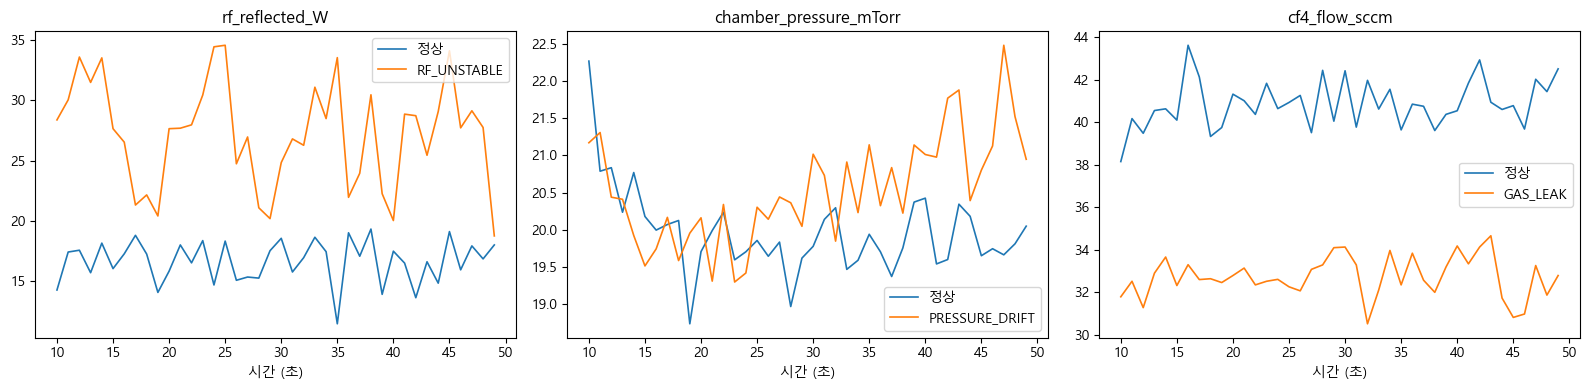

In [151]:
# TODO 4-1: 유형별로 웨이퍼 하나씩 고르기
#   힌트: wi[wi.fault_type == 'RF_UNSTABLE'].wafer_id.iloc[0]
#   RF_UNSTABLE, PRESSURE_DRIFT, GAS_LEAK 세 개를 {유형: wafer_id} 딕셔너리로
picks = {'RF_UNSTABLE': wi[wi.fault_type == 'RF_UNSTABLE'].wafer_id.iloc[0],
         'PRESSURE_DRIFT': wi[wi.fault_type == 'PRESSURE_DRIFT'].wafer_id.iloc[0],
         'GAS_LEAK': wi[wi.fault_type == 'GAS_LEAK'].wafer_id.iloc[0]}
print(picks)

# TODO 4-2: 유형마다 알맞은 센서를 골라 정상과 겹쳐 그리기
#   1행 3열 subplot 을 쓰고, MainEtch 구간만 그려도 좋습니다
#   센서는 이상 이름에서 짐작할 수 있습니다. RF 가 불안하면 어느 신호를 봐야 할까요.
#   정상 웨이퍼와 반드시 같은 축에 겹쳐 그리세요. 따로 그리면 y축 범위가 달라
#   차이가 있어도 안 보입니다

main = tr[tr['step'] == 'MainEtch']
base = main[main['wafer_id'] == 'WF0002']

fig, axes = plt.subplots(1, 3, figsize=(16,4), sharex=True)

axes.ravel()[0].plot(base['t_sec'], base['rf_reflected_W'], linewidth=1.2, label='정상')
axes.ravel()[0].plot(main['t_sec'][main['wafer_id'] == picks['RF_UNSTABLE']], main['rf_reflected_W'][main['wafer_id'] == picks['RF_UNSTABLE']], linewidth=1.2, label='RF_UNSTABLE')
axes.ravel()[0].set_title('rf_reflected_W')
axes.ravel()[0].set_xlabel('시간 (초)')

axes.ravel()[1].plot(base['t_sec'], base['chamber_pressure_mTorr'], linewidth=1.2, label='정상')
axes.ravel()[1].plot(main['t_sec'][main['wafer_id'] == picks['PRESSURE_DRIFT']], main['chamber_pressure_mTorr'][main['wafer_id'] == picks['PRESSURE_DRIFT']], linewidth=1.2, label='PRESSURE_DRIFT')
axes.ravel()[1].set_title('chamber_pressure_mTorr')
axes.ravel()[1].set_xlabel('시간 (초)')

axes.ravel()[2].plot(base['t_sec'], base['cf4_flow_sccm'], linewidth=1.2, label='정상')
axes.ravel()[2].plot(main['t_sec'][main['wafer_id'] == picks['GAS_LEAK']], main['cf4_flow_sccm'][main['wafer_id'] == picks['GAS_LEAK']], linewidth=1.2, label='GAS_LEAK')
axes.ravel()[2].set_title('cf4_flow_sccm')
axes.ravel()[2].set_xlabel('시간 (초)')

# 이거 없으면 이상하게 붙어서 나오는듯
plt.tight_layout()
axes[0].legend()
axes[1].legend()
axes[2].legend()
plt.show()


자가진단 4 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [93]:
check('세 유형 선택', picks is not None and len(picks) == 3)
check('선택한 웨이퍼가 실제 그 유형인가',
      picks is not None and all(wi.set_index('wafer_id').fault_type[v] == k for k, v in picks.items()))

[통과] 세 유형 선택
[통과] 선택한 웨이퍼가 실제 그 유형인가


---

## 미션 5 · 웨이퍼 한 장을 한 줄로 줄이기

모델에 넣으려면 웨이퍼 한 장이 한 줄이어야 합니다. 지금은 60줄입니다.
그래서 **요약통계**로 줄입니다.

MainEtch 구간만 골라서, 센서 여덟 개 각각의 평균·표준편차·최솟값·최댓값을 구하세요.
8 × 4 = 32개 값이 나옵니다. 이게 웨이퍼 한 장을 대표하는 한 줄이 됩니다.

MainEtch만 쓰는 이유는 이상이 거의 거기서 나오기 때문입니다.
Stabilize 는 RF가 꺼져 있어 넣어봐야 잡음만 늘어납니다.

In [115]:
# TODO 5-1: MainEtch 구간만 뽑기 (16000행이어야 합니다)
main = main = tr[tr['step'] == 'MainEtch']

# TODO 5-2: 웨이퍼별로 센서 8개의 mean/std/min/max 구하기
#   힌트: main.groupby('wafer_id')[SENSORS].agg(['mean','std','min','max'])
feat = main.groupby('wafer_id')[SENSORS].agg(['mean', 'std', 'min', 'max'])

# TODO 5-3: 컬럼 이름을 rf_forward_W_mean 처럼 한 층으로 펴기
feat.columns = ['_'.join(c) for c in feat.columns]
print(feat.columns)
#   힌트: feat.columns = ['_'.join(c) for c in feat.columns]

Index(['rf_forward_W_mean', 'rf_forward_W_std', 'rf_forward_W_min',
       'rf_forward_W_max', 'rf_reflected_W_mean', 'rf_reflected_W_std',
       'rf_reflected_W_min', 'rf_reflected_W_max',
       'chamber_pressure_mTorr_mean', 'chamber_pressure_mTorr_std',
       'chamber_pressure_mTorr_min', 'chamber_pressure_mTorr_max',
       'ar_flow_sccm_mean', 'ar_flow_sccm_std', 'ar_flow_sccm_min',
       'ar_flow_sccm_max', 'cf4_flow_sccm_mean', 'cf4_flow_sccm_std',
       'cf4_flow_sccm_min', 'cf4_flow_sccm_max', 'esc_temp_C_mean',
       'esc_temp_C_std', 'esc_temp_C_min', 'esc_temp_C_max',
       'he_backside_Torr_mean', 'he_backside_Torr_std', 'he_backside_Torr_min',
       'he_backside_Torr_max', 'endpoint_intensity_mean',
       'endpoint_intensity_std', 'endpoint_intensity_min',
       'endpoint_intensity_max'],
      dtype='object')


자가진단 5 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [116]:
check('MainEtch 16000행', main is not None and len(main) == 16000, None if main is None else len(main))
check('특징 400행 32열', feat is not None and feat.shape == (400, 32), None if feat is None else feat.shape)
check('컬럼명 평탄화', feat is not None and 'rf_reflected_W_max' in feat.columns)

[통과] MainEtch 16000행
[통과] 특징 400행 32열
[통과] 컬럼명 평탄화


---

## 미션 6 · 기울기라는 특징 만들기

`PRESSURE_DRIFT` 는 압력이 **서서히 올라가는** 이상입니다.
그런데 평균이나 최댓값으로는 잘 안 잡힙니다. 평균은 오르든 내리든 비슷하게 나오니까요.

필요한 건 **기울기**입니다. 시간에 대해 직선을 맞춰서 그 기울기를 구합니다.

```python
np.polyfit(x, y, 1)[0]    # 1차 다항식을 맞추고 기울기만 꺼냄
```

웨이퍼별로 MainEtch 구간 압력의 기울기를 구해 `pressure_slope` 컬럼으로 붙이세요.

이렇게 도메인을 알고 특징을 새로 만드는 걸 특징 공학이라고 합니다.
다음 주에 이 특징이 제일 중요하게 나옵니다.

In [132]:
# TODO 6-1: 웨이퍼별 압력 기울기
#   힌트: main.groupby('wafer_id').apply(lambda g: np.polyfit(g.t_sec, g.chamber_pressure_mTorr, 1)[0])
slope = main.groupby('wafer_id').apply(lambda g: np.polyfit(g.t_sec, g.chamber_pressure_mTorr, 1)[0])

# TODO 6-2: slope를 feat 에  pressure_slope 컬럼으로 붙이고 wafer_info 와 합치기
#   feat 의 인덱스가 wafer_id 이므로 reset_index() 한 뒤 wi 와 merge 하세요
#   결과는 400행이고 fault_type 컬럼이 들어 있어야 합니다

feat['pressure_slope'] = slope
data = pd.merge(feat.reset_index(), wi)

# TODO 6-3: 이상 유형별 기울기 평균 출력
#   PRESSURE_DRIFT 만 튀는지 확인하세요
print(data['pressure_slope'][data['fault_type'] == 'RF_UNSTABLE'].mean())
print(data['pressure_slope'][data['fault_type'] == 'PRESSURE_DRIFT'].mean())
print(data['pressure_slope'][data['fault_type'] == 'GAS_LEAK'].mean())

-0.02376854909318336
0.031061438398999296
-0.02218175422138846


C:\Users\user\AppData\Local\Temp\ipykernel_71648\3314791646.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slope = main.groupby('wafer_id').apply(lambda g: np.polyfit(g.t_sec, g.chamber_pressure_mTorr, 1)[0])


자가진단 6 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [128]:
check('기울기 400개', slope is not None and len(slope) == 400)
check('data 결합', data is not None and 'fault_type' in data.columns and len(data) == 400)
check('DRIFT 기울기가 가장 큼',
      data is not None and data.groupby('fault_type').pressure_slope.mean().idxmax() == 'PRESSURE_DRIFT')

[통과] 기울기 400개
[통과] data 결합
[통과] DRIFT 기울기가 가장 큼


---

## 미션 7 · 어떤 특징이 어떤 이상을 잡는가

이제 특징 33개가 생겼습니다. 어떤 게 어떤 이상에 반응하는지 봅시다.

아래 세 특징을 골라 이상 유형별 박스플롯을 그리세요.

- `rf_reflected_W_max`
- `pressure_slope`
- `cf4_flow_sccm_mean`

그리고 나서 각 특징이 어느 유형을 잘 갈라주는지, 잘 못 갈라주는 유형은 없는지 보세요.
특히 `GAS_LEAK` 을 눈여겨보세요. 정상과 얼마나 겹칩니까.

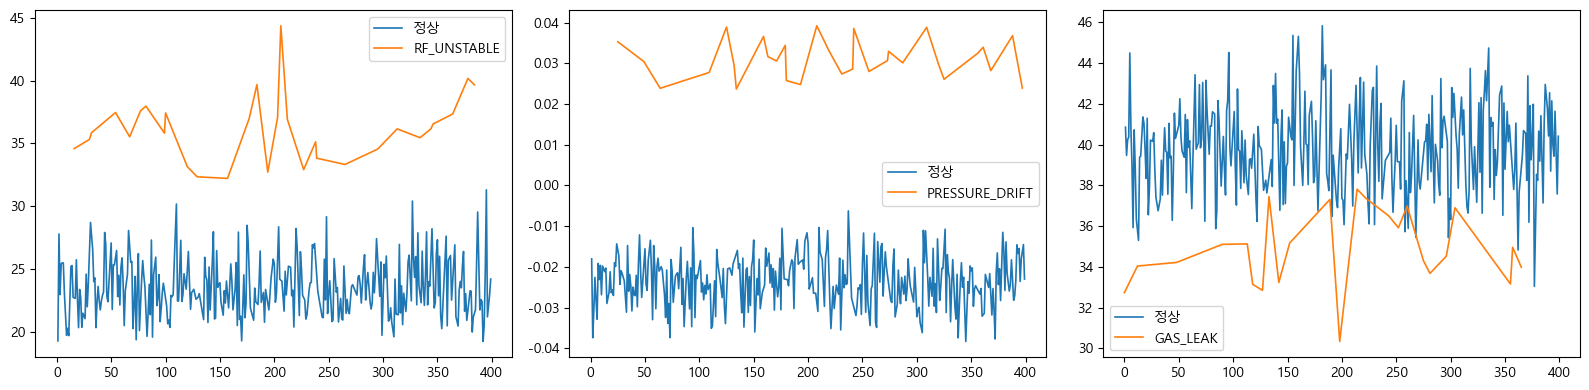

                rf_reflected_W_max  pressure_slope  cf4_flow_sccm_mean
fault_type                                                            
GAS_LEAK                 23.515833       -0.022182           34.867635
NORMAL                   23.519272       -0.023598           39.760036
PRESSURE_DRIFT           22.710667        0.031061           40.000875
RF_UNSTABLE              36.144333       -0.023769           39.554925


In [149]:
# TODO 7-1: 세 특징을 이상 유형별 박스플롯으로 (1행 3열)
#   ORDER 순서로 그리면 표와 그림을 나란히 읽기 좋습니다
PICK = ['rf_reflected_W_max', 'pressure_slope', 'cf4_flow_sccm_mean']
ORDER = ['NORMAL', 'RF_UNSTABLE', 'PRESSURE_DRIFT', 'GAS_LEAK']

fig, axes = plt.subplots(1, 3, figsize=(16,4), sharex=True)
axes.ravel()[0].plot(data['rf_reflected_W_max'][data['fault_type'] == 'NORMAL'], linewidth=1.2, label='정상')
axes.ravel()[0].plot(data['rf_reflected_W_max'][data['fault_type'] == 'RF_UNSTABLE'], linewidth=1.2, label='RF_UNSTABLE')

axes.ravel()[1].plot(data['pressure_slope'][data['fault_type'] == 'NORMAL'], linewidth=1.2, label='정상')
axes.ravel()[1].plot(data['pressure_slope'][data['fault_type'] == 'PRESSURE_DRIFT'], linewidth=1.2, label='PRESSURE_DRIFT')

axes.ravel()[2].plot(data['cf4_flow_sccm_mean'][data['fault_type'] == 'NORMAL'], linewidth=1.2, label='정상')
axes.ravel()[2].plot(data['cf4_flow_sccm_mean'][data['fault_type'] == 'GAS_LEAK'], linewidth=1.2, label='GAS_LEAK')

plt.tight_layout()
axes[0].legend()
axes[1].legend()
axes[2].legend()
plt.show()

# TODO 7-2: 유형별 평균을 표로
#   fault_type 으로 묶어 PICK 세 컬럼의 평균을 내세요 (4행 3열)
summary = data.groupby('fault_type')[PICK].mean()
print(summary)

# TODO 7-3: GAS_LEAK 은 정상과 얼마나 겹칩니까? (주석으로)
#   답: 전체적으로는 정상보다 낮은 경향이 있지만 평균이 정상 값과 겹치는 부분들이 분명히 존재합니다.

자가진단 7 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [150]:
check('요약표 4행', summary is not None and len(summary) == 4)
check('RF 반사전력 최대는 RF_UNSTABLE 이 1위',
      summary is not None and summary.rf_reflected_W_max.idxmax() == 'RF_UNSTABLE')
check('CF4 평균은 GAS_LEAK 이 최소',
      summary is not None and summary.cf4_flow_sccm_mean.idxmin() == 'GAS_LEAK')

[통과] 요약표 4행
[통과] RF 반사전력 최대는 RF_UNSTABLE 이 1위
[통과] CF4 평균은 GAS_LEAK 이 최소


---

## 미션 8 · 정리해서 쓰기

코드가 아니라 글입니다. 숫자를 근거로 인용하세요.

---

**1. 이 데이터는 지난 두 주와 무엇이 다른가**

웨이퍼 한 장이 몇 줄입니까. 왜 그렇습니까.

답: 웨이퍼 한 장은 60줄입니다. 이는 한 웨이퍼당 한 데이터만 뽑은 것이 아니라 t_sec(1초)마다 받아온 웨이퍼의 데이터가 전부 들어간 시계열 데이터이기 때문입니다.

**2. 60줄을 1줄로 줄일 때 무엇을 잃는가**

평균과 표준편차만 남기면 사라지는 정보가 있습니다. 무엇입니까.

답: 평균과 표준편차가 있다면 평균과 데이터들이 평균으로부터 분산된 정도는 알 수 있으나, 60줄 중 구체적으로 어떤 값이 튀는지는 알 수 없습니다.

**3. 왜 MainEtch 구간만 썼는가**

Stabilize 와 Overetch 를 뺀 이유를 설명하세요.

답: 공정이 직접 진행되는

**4. 기울기는 왜 따로 만들어야 했나**

평균이나 최댓값으로 `PRESSURE_DRIFT` 를 못 잡는 이유를 쓰세요.

답:

**5. 세 가지 이상 중 어느 것이 가장 찾기 어려울 것 같은가**

미션 7의 박스플롯을 근거로 답하세요.

답:

**6. 이 특징들로 놓치게 될 이상은 무엇일까**

요약통계 33개로는 잡을 수 없는 이상을 상상해서 쓰세요. 최소 두 가지.
힌트: 순간적으로 튀었다 돌아오는 이상은? 두 센서의 관계가 틀어지는 이상은?

답:

---

### 제출 전 확인

- [ ] 자가진단이 모두 `[통과]` 인가
- [ ] 그래프 네 개(센서 8칸, 겹쳐 그리기, 박스플롯)에 제목과 축 이름이 있는가
- [ ] 미션 8의 여섯 항목을 본인 문장으로 채웠는가
- [ ] 커널 재시작 후 전체 실행이 오류 없이 끝나는가
- [ ] 파일명을 `W03_학번_이름.ipynb` 로 바꿨는가